In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
omkarmanohardalvi_lungs_disease_dataset_4_types_path = kagglehub.dataset_download('omkarmanohardalvi/lungs-disease-dataset-4-types')

print('Data source import complete.')


Using Colab cache for faster access to the 'lungs-disease-dataset-4-types' dataset.
Data source import complete.


# **Lung Disease Classification Using InceptionV3 + ViT**

## **Overview**
This notebook implements a multi-stage deep learning model combining **InceptionV3** and **Vision Transformer (ViT)** for lung disease classification.

### **Dataset**
- **Source**: Lung Disease Dataset (4 Types)
- **Classes**: 4 classes after combining pneumonia types
  - Normal
  - COVID-19
  - Lung Opacity
  - Pneumonia (Bacterial + Viral combined)

### **Model Architecture**
- **CNN Backbone**: InceptionV3 (pretrained on ImageNet)
- **Transformer**: ViT-Base-Patch16-224
- **Combined Features**: CNN (2048) + ViT (768) = 2816 dimensional feature vector
- **Classifier**: Fully connected layer

### **Key Features**
✓ Data preprocessing with pneumonia class combination  
✓ Multi-stage CNN + Transformer architecture  
✓ Comprehensive evaluation metrics  
✓ Multiple visualization graphs  
✓ Confusion matrix analysis  
✓ ROC curves for all classes  
✓ Grad-CAM visualization for model interpretability

# **Imports & Config**

# **Data Preparation - Combine Pneumonia Classes**

In [2]:
import shutil
import os

# Get the original dataset path
original_dataset_path = os.path.join(omkarmanohardalvi_lungs_disease_dataset_4_types_path, "Lung Disease Dataset")

# Define a new writable path for processing
output_base_path = "/content/processed_dataset"

# First, copy the entire dataset to a writable location
print(f"Copying dataset from {original_dataset_path} to {output_base_path}...")
#shutil.copytree(original_dataset_path, output_base_path)
shutil.copytree(original_dataset_path, output_base_path, dirs_exist_ok=True)
print("Dataset copied successfully to writable location.")

# Function to combine pneumonia classes in the new writable location
def combine_pneumonia_classes(base_path):
    """
    Combines Bacterial Pneumonia and Viral Pneumonia into a single Pneumonia class
    """
    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)

        # Create Pneumonia directory if it doesn't exist
        pneumonia_dir = os.path.join(split_path, 'Pneumonia')
        os.makedirs(pneumonia_dir, exist_ok=True)

        # Copy files from Bacterial Pneumonia
        bacterial_dir = os.path.join(split_path, 'Bacterial Pneumonia')
        if os.path.exists(bacterial_dir):
            num_copied_bacterial = 0
            for filename in os.listdir(bacterial_dir):
                src = os.path.join(bacterial_dir, filename)
                dst = os.path.join(pneumonia_dir, f'bacterial_{filename}')
                if os.path.isfile(src):
                    shutil.copy2(src, dst)
                    num_copied_bacterial += 1
            print(f"Copied {num_copied_bacterial} files from {bacterial_dir}")
            # Optionally remove original bacterial directory after copying
            shutil.rmtree(bacterial_dir)

        # Copy files from Viral Pneumonia
        viral_dir = os.path.join(split_path, 'Viral Pneumonia')
        if os.path.exists(viral_dir):
            num_copied_viral = 0
            for filename in os.listdir(viral_dir):
                src = os.path.join(viral_dir, filename)
                dst = os.path.join(pneumonia_dir, f'viral_{filename}')
                if os.path.isfile(src):
                    shutil.copy2(src, dst)
                    num_copied_viral += 1
            print(f"Copied {num_copied_viral} files from {viral_dir}")
            # Optionally remove original viral directory after copying
            shutil.rmtree(viral_dir)

        print(f"Combined pneumonia classes in {split_path}")
        print(f"Total Pneumonia images: {len(os.listdir(pneumonia_dir))}")
        print()

# Combine pneumonia classes in the new writable dataset path
print("Combining Bacterial and Viral Pneumonia into single Pneumonia class...")
combine_pneumonia_classes(output_base_path)

# Update dataset_path to point to the new processed directory
dataset_path = output_base_path

# Update train_dir and test_dir for subsequent cells
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Data preparation complete!")


Copying dataset from /kaggle/input/lungs-disease-dataset-4-types/Lung Disease Dataset to /content/processed_dataset...
Dataset copied successfully to writable location.
Combining Bacterial and Viral Pneumonia into single Pneumonia class...
Copied 1205 files from /content/processed_dataset/train/Bacterial Pneumonia
Copied 1204 files from /content/processed_dataset/train/Viral Pneumonia
Combined pneumonia classes in /content/processed_dataset/train
Total Pneumonia images: 2409

Copied 403 files from /content/processed_dataset/test/Bacterial Pneumonia
Copied 403 files from /content/processed_dataset/test/Viral Pneumonia
Combined pneumonia classes in /content/processed_dataset/test
Total Pneumonia images: 806

Data preparation complete!


In [3]:
# Display class distribution after combining
print("\n" + "="*50)
print("CLASS DISTRIBUTION AFTER COMBINING PNEUMONIA")
print("="*50)

for split in ['train', 'test']:
    split_path = os.path.join(dataset_path, split)
    print(f"\n{split.upper()} SET:")
    print("-" * 40)

    if os.path.exists(split_path):
        classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            num_images = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
            print(f"  {cls:25s}: {num_images:5d} images")

print("\n" + "="*50)


CLASS DISTRIBUTION AFTER COMBINING PNEUMONIA

TRAIN SET:
----------------------------------------
  Corona Virus Disease     :  1218 images
  Normal                   :  1207 images
  Pneumonia                :  2409 images
  Tuberculosis             :  1220 images

TEST SET:
----------------------------------------
  Corona Virus Disease     :   407 images
  Normal                   :   404 images
  Pneumonia                :   806 images
  Tuberculosis             :   408 images



In [4]:
import os
import json
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import inception_v3
from transformers import ViTModel
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Configurations
BATCH_SIZE = 32
IMG_SIZE = 299  # InceptionV3 uses 299x299 images
NUM_CLASSES = 4  # Changed from 5 to 4 (combining pneumonia types)
EPOCHS = 10
LEARNING_RATE = 1e-4

train_dir = "/kaggle/input/lungs-disease-dataset-4-types/Lung Disease Dataset/train"
test_dir = "/kaggle/input/lungs-disease-dataset-4-types/Lung Disease Dataset/test"

## **Installation (Run if needed)**
Uncomment and run the cell below if you need to install required packages

In [5]:
# Uncomment the following lines if running in Google Colab or if packages are missing
# !pip install torch torchvision
# !pip install transformers
# !pip install scikit-learn
# !pip install seaborn matplotlib
# !pip install opencv-python-headless

print("If packages are already installed, you can skip this cell.")

If packages are already installed, you can skip this cell.


# **Transforms & DataLoaders**

In [6]:
import os

# Point to the PROCESSED dataset created in the earlier cell
# Instead of the original Kaggle path
train_dir = "/content/processed_dataset/train"
test_dir = "/content/processed_dataset/test"

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = ImageFolder(train_dir, transform=transform)
test_data = ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# Save class index mapping
with open("class_mapping.json", "w") as f:
    json.dump(train_data.class_to_idx, f)

print(f"DataLoaders initialized with classes: {train_data.classes}")

DataLoaders initialized with classes: ['Corona Virus Disease', 'Normal', 'Pneumonia', 'Tuberculosis']


# **Model Definition - InceptionV3 + ViT**

## **Architecture Overview:**
- **InceptionV3**: Pre-trained CNN backbone that extracts 2048-dimensional features
  - Input: 299x299 images
  - Multi-scale feature extraction through inception modules
- **ViT (Vision Transformer)**: Pre-trained transformer model extracting 768-dimensional features
  - Input: 224x224 images (resized internally)
  - Captures global context through self-attention
- **Fusion**: Concatenate both feature vectors → 2816 dimensions
- **Classifier**: Final fully connected layer for 4-class classification

In [7]:
class MultiStageInceptionViT(nn.Module):
    def __init__(self, num_classes):
        super(MultiStageInceptionViT, self).__init__()
        # Load InceptionV3 backbone
        self.backbone_cnn = inception_v3(pretrained=True, aux_logits=False)
        # Remove the final classifier
        self.backbone_cnn.fc = nn.Identity()  # InceptionV3 outputs 2048 features

        # Load ViT backbone
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

        # Combined classifier
        self.fc = nn.Linear(2048 + self.vit.config.hidden_size, num_classes)

    def forward(self, x):
        # CNN path
        cnn_out = self.backbone_cnn(x)

        # ViT path (resize input to 224x224 for ViT)
        vit_input = torch.nn.functional.interpolate(x, size=(224, 224))
        vit_out = self.vit(pixel_values=vit_input).pooler_output

        # Combine features
        combined = torch.cat((cnn_out, vit_out), dim=1)
        return self.fc(combined)

# **Initialization & Evaluation Function**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Redefining the class to fix the aux_logits and torchvision attribute error
class MultiStageInceptionViT(nn.Module):
    def __init__(self, num_classes):
        super(MultiStageInceptionViT, self).__init__()
        # InceptionV3 requires aux_logits=True for pretrained weights in recent torchvision versions
        self.backbone_cnn = inception_v3(pretrained=True, aux_logits=True)
        self.backbone_cnn.AuxLogits = None # Disable auxiliary classifier
        self.backbone_cnn.fc = nn.Identity()

        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.fc = nn.Linear(2048 + self.vit.config.hidden_size, num_classes)

    def forward(self, x):
        # InceptionV3 returns a named tuple if aux_logits is enabled
        cnn_out = self.backbone_cnn(x)

        # Fix: Check for InceptionOutputs correctly. If aux_logits was True, cnn_out is a tuple/namedtuple.
        if not torch.is_tensor(cnn_out):
             cnn_out = cnn_out.logits

        vit_input = torch.nn.functional.interpolate(x, size=(224, 224))
        vit_out = self.vit(pixel_values=vit_input).pooler_output

        combined = torch.cat((cnn_out, vit_out), dim=1)
        return self.fc(combined)

model = MultiStageInceptionViT(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def evaluate(model, dataloader):
    model.eval()
    total_correct = 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    acc = total_correct / len(dataloader.dataset)
    return acc, all_preds, all_labels, np.array(all_probs)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

# **Training Loop**

In [9]:
# Track training history
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = total_correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

Epoch [1/10] - Train Loss: 0.2005, Train Acc: 0.9272
Epoch [2/10] - Train Loss: 0.0613, Train Acc: 0.9787
Epoch [3/10] - Train Loss: 0.0296, Train Acc: 0.9906
Epoch [4/10] - Train Loss: 0.0222, Train Acc: 0.9931
Epoch [5/10] - Train Loss: 0.0254, Train Acc: 0.9922
Epoch [6/10] - Train Loss: 0.0099, Train Acc: 0.9972
Epoch [7/10] - Train Loss: 0.0195, Train Acc: 0.9931
Epoch [8/10] - Train Loss: 0.0332, Train Acc: 0.9891
Epoch [9/10] - Train Loss: 0.0203, Train Acc: 0.9926
Epoch [10/10] - Train Loss: 0.0046, Train Acc: 0.9992


In [10]:
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Initial Training Loss: {train_losses[0]:.4f}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Loss Improvement: {train_losses[0] - train_losses[-1]:.4f}")
print()
print(f"Initial Training Accuracy: {train_accuracies[0]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Accuracy Improvement: {(train_accuracies[-1] - train_accuracies[0]):.4f}")
print("="*50)


TRAINING SUMMARY
Initial Training Loss: 0.2005
Final Training Loss: 0.0046
Loss Improvement: 0.1959

Initial Training Accuracy: 0.9272
Final Training Accuracy: 0.9992
Accuracy Improvement: 0.0720


# **Final Evaluation & Visualization**


FINAL MODEL EVALUATION

Overall Test Accuracy: 0.9802

--------------------------------------------------
Per-Class Metrics:
--------------------------------------------------
Class: Corona Virus Disease | Precision: 1.0000 | Recall: 0.9902 | F1: 0.9951 | Accuracy: 0.9902 | Support: 407
Class: Normal               | Precision: 0.9277 | Recall: 0.9851 | F1: 0.9556 | Accuracy: 0.9851 | Support: 404
Class: Pneumonia            | Precision: 0.9923 | Recall: 0.9628 | F1: 0.9773 | Accuracy: 0.9628 | Support: 806
Class: Tuberculosis         | Precision: 0.9927 | Recall: 1.0000 | F1: 0.9963 | Accuracy: 1.0000 | Support: 408

--------------------------------------------------
Classification Report:
--------------------------------------------------
                      precision    recall  f1-score   support

Corona Virus Disease       1.00      0.99      1.00       407
              Normal       0.93      0.99      0.96       404
           Pneumonia       0.99      0.96      0.98       806


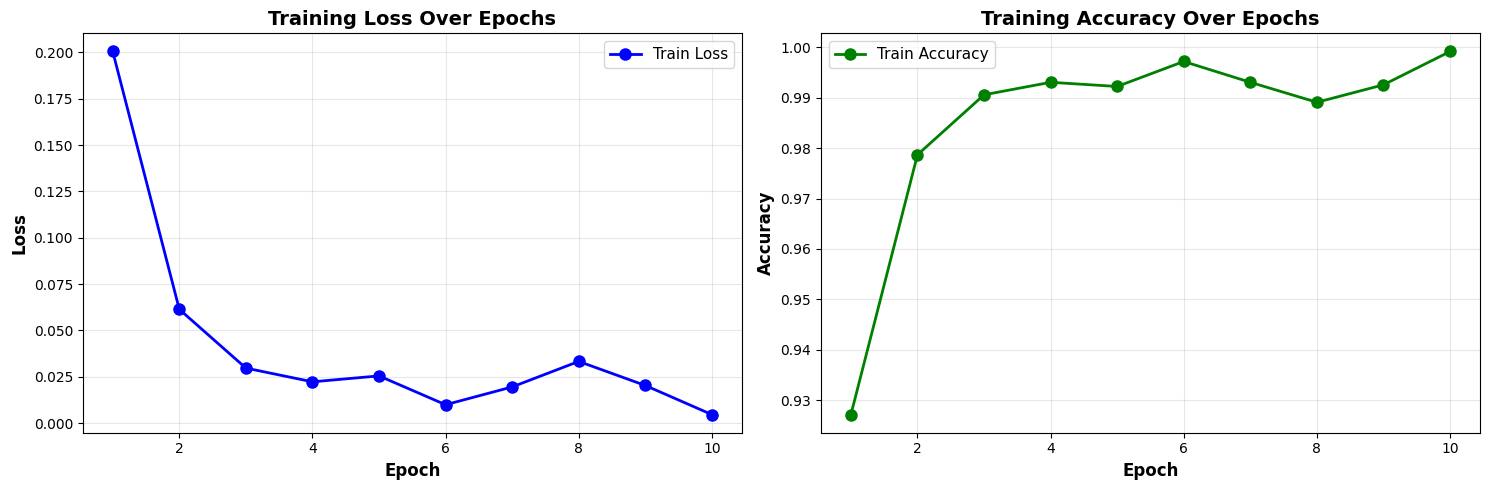

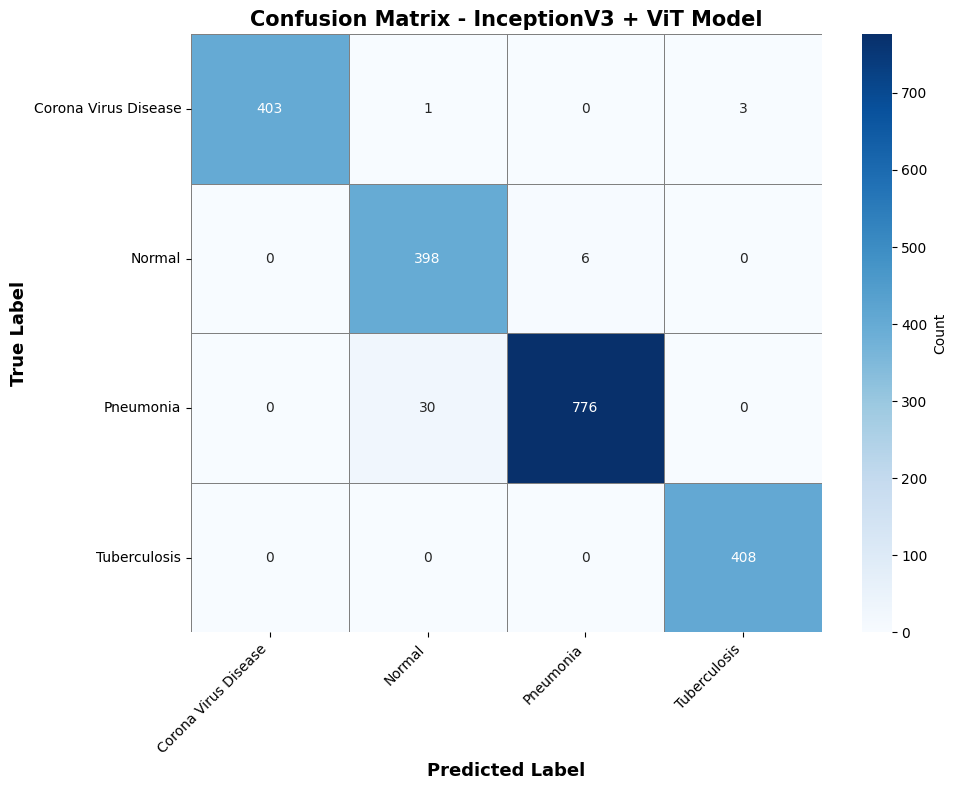

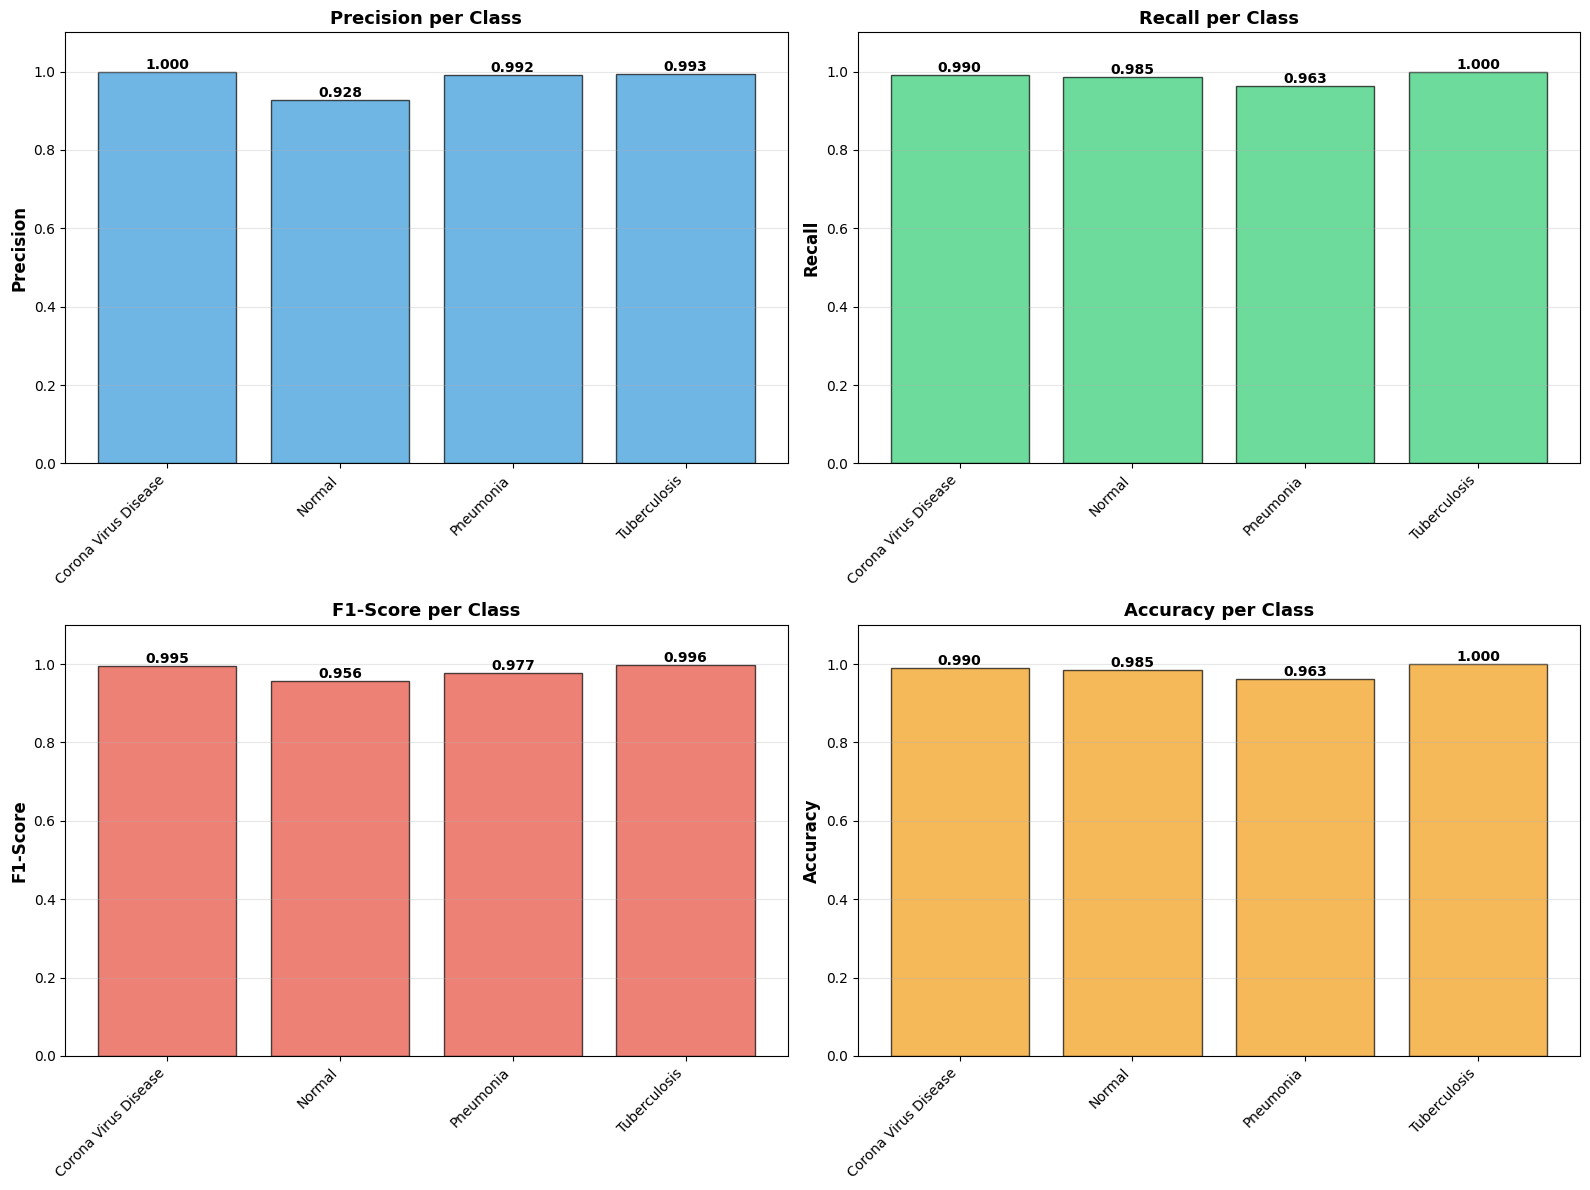

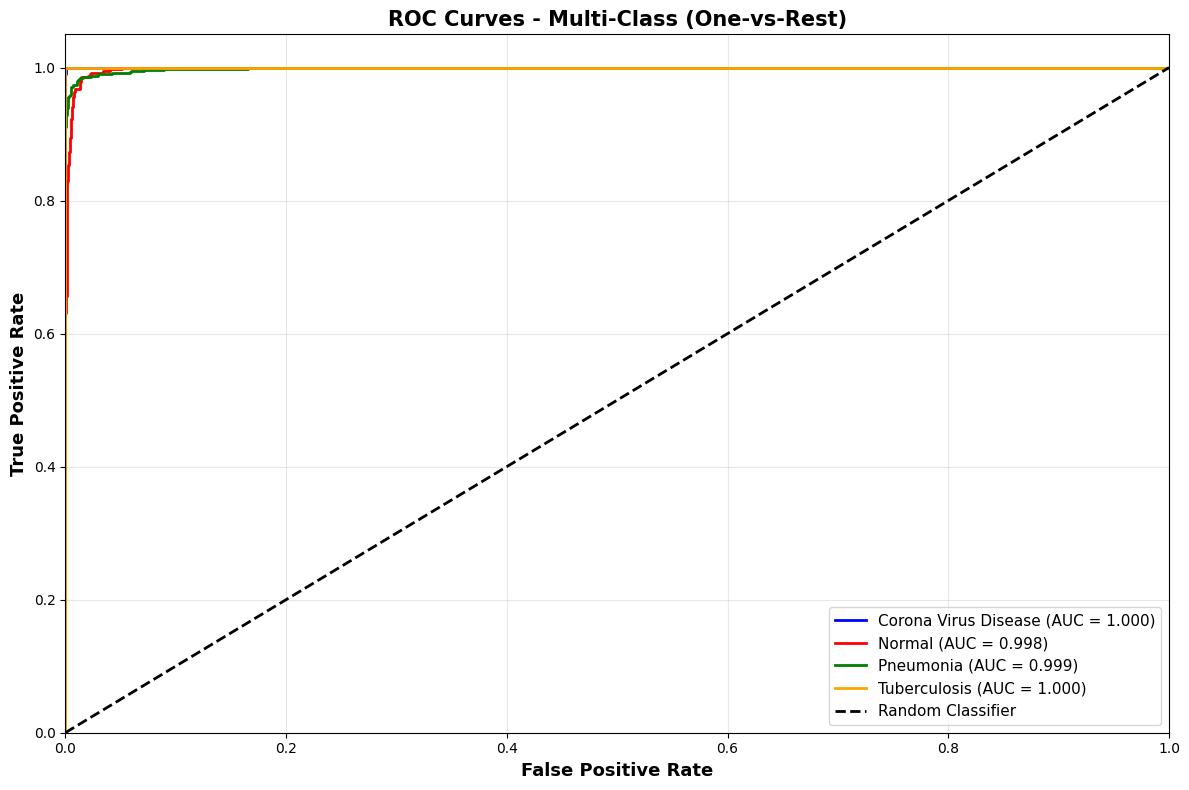

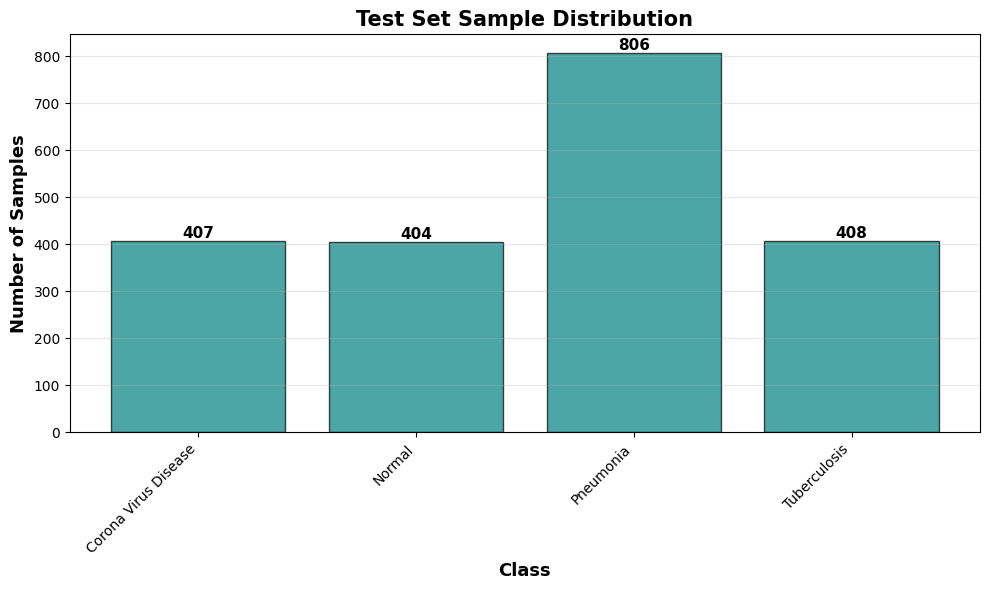


Evaluation Complete!


In [11]:
print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

# Evaluate on test set
test_acc, test_preds, test_labels, test_probs = evaluate(model, test_loader)
cm = confusion_matrix(test_labels, test_preds)
precision, recall, f1, support = precision_recall_fscore_support(test_labels, test_preds, zero_division=0)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print(f"\nOverall Test Accuracy: {test_acc:.4f}")
print("\n" + "-"*50)
print("Per-Class Metrics:")
print("-"*50)
for i, cls in enumerate(train_data.classes):
    print(f"Class: {cls:20s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f} | Accuracy: {per_class_acc[i]:.4f} | Support: {int(support[i])}")

print("\n" + "-"*50)
print("Classification Report:")
print("-"*50)
print(classification_report(test_labels, test_preds, target_names=train_data.classes, zero_division=0))

# ==================== VISUALIZATIONS ====================

# 1. Training History (Loss and Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'b-o', linewidth=2, markersize=8, label='Train Loss')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

axes[1].plot(epochs_range, train_accuracies, 'g-o', linewidth=2, markersize=8, label='Train Accuracy')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Training Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data.classes, yticklabels=train_data.classes,
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')
plt.xlabel("Predicted Label", fontsize=13, fontweight='bold')
plt.ylabel("True Label", fontsize=13, fontweight='bold')
plt.title("Confusion Matrix - InceptionV3 + ViT Model", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Per-Class Performance Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [precision, recall, f1, per_class_acc]
metric_names = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, (ax, metric, name, color) in enumerate(zip(axes.flatten(), metrics, metric_names, colors)):
    bars = ax.bar(train_data.classes, metric, color=color, alpha=0.7, edgecolor='black')
    ax.set_ylabel(name, fontsize=12, fontweight='bold')
    ax.set_title(f'{name} per Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(train_data.classes, rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. ROC Curves (One-vs-Rest)
# Binarize the labels for multi-class ROC
y_test_binarized = label_binarize(test_labels, classes=range(NUM_CLASSES))

plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange']

for i, (cls, color) in enumerate(zip(train_data.classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - Multi-Class (One-vs-Rest)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Support (Sample Count) per Class
plt.figure(figsize=(10, 6))
bars = plt.bar(train_data.classes, support, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Class', fontsize=13, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=13, fontweight='bold')
plt.title('Test Set Sample Distribution', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Evaluation Complete!")
print("="*50)

# **Save Model**

In [12]:
torch.save(model.state_dict(), "inceptionv3_vit_lung.pth")
print("Model saved successfully as 'inceptionv3_vit_lung.pth'")

Model saved successfully as 'inceptionv3_vit_lung.pth'


# Task
Load the pre-trained model and class mapping, define a preprocessing pipeline for individual images, implement the Grad-CAM algorithm to visualize important regions of an image, and apply it to a test image from "test_dir" to display the original image, its predicted class, and the generated Grad-CAM heatmap.

## Load Model and Class Mapping

### Subtask:
Load the pre-trained MultistageEfficientNetViT model from 'efficientnet_vit_lung.pth' and the class index mapping from 'class_mapping.json'.


**Reasoning**:
The subtask requires loading the pre-trained model and the class mapping. This code block will instantiate the model, load its state dictionary, set it to evaluation mode, and then load the class index mapping from the JSON file.



In [13]:
model = MultiStageInceptionViT(NUM_CLASSES).to(device)
model.load_state_dict(torch.load("inceptionv3_vit_lung.pth"))
model.eval()

with open("class_mapping.json", "r") as f:
    class_to_idx = json.load(f)

print("Model and class mapping loaded successfully.")
print(f"Classes: {list(class_to_idx.keys())}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model and class mapping loaded successfully.
Classes: ['Corona Virus Disease', 'Normal', 'Pneumonia', 'Tuberculosis']


# Task
Define a function `preprocess_image` that takes an image path, loads the image, and applies the necessary transformations (resize, convert to tensor, normalize) consistent with the training data. This function should return the preprocessed image tensor. Additionally, select a sample image path from the `test_dir` to be used for testing this function.

## Image Preprocessing

### Subtask:
Define a function to load an image from a specified path and apply the necessary transformations (resize, convert to tensor, normalize) consistent with the training data. Additionally, select a sample image path from the `test_dir` to be used for testing this function.


**Reasoning**:
To preprocess individual images for Grad-CAM, I need to define a function that loads an image, applies the same transformations used during training, and adds a batch dimension. Additionally, I'll select a sample image from the test directory to demonstrate this function.



In [14]:
import os
from PIL import Image

def preprocess_image(image_path):
    image = Image.open(image_path).convert('RGB')
    transformed_image = transform(image)
    return transformed_image.unsqueeze(0)

# Select a sample image path from test_dir
# Assuming 'Normal' is one of the subdirectories in test_dir
class_name = list(class_to_idx.keys())[2] # Using 'Normal' class for example
class_dir = os.path.join(test_dir, class_name)

# Check if the class_dir exists and contains files
if os.path.exists(class_dir) and os.listdir(class_dir):
    sample_image_filename = os.listdir(class_dir)[0]
    sample_image_path = os.path.join(class_dir, sample_image_filename)
    print(f"Selected sample image: {sample_image_path}")
else:
    print(f"Directory {class_dir} is empty or does not exist. Cannot select sample image.")
    # Fallback or error handling if no images are found in 'Normal' class
    # For robust handling, one might iterate through all classes until an image is found
    sample_image_path = None # Set to None if no image can be found


Selected sample image: /content/processed_dataset/test/Pneumonia/bacterial_602.jpeg


## Grad-CAM Implementation

### Subtask:
Implement the Grad-CAM algorithm to visualize important regions of an image for model prediction. This involves defining a `GradCAM` class that extracts feature maps and gradients from specified layers of the model, and then computes and superimposes a heatmap onto the original image.

#### Instructions:
1. Define a `GradCAM` class.
2. In the `__init__` method, take `model`, `target_layer`, and `target_vit_layer` as arguments. Store references to the feature extractor and classifier portions of the model. Register forward and backward hooks to capture feature maps and gradients from the `target_layer` (for the CNN backbone) and `target_vit_layer` (for the ViT part).
3. Implement a `__call__` method that takes an input image tensor, performs a forward pass, and computes the Grad-CAM heatmap. This method should:
    a. Zero out gradients and set the model to evaluation mode.
    b. Perform a forward pass to get model output and store feature maps and gradients.
    c. Identify the predicted class.
    d. Zero out all gradients except for the predicted class's output.
    e. Perform a backward pass to compute gradients.
    f. Compute the importance weights (alpha) by globally averaging the gradients for each feature map.
    g. Compute the heatmap by taking a weighted sum of the feature maps, applying ReLU, and normalizing.
    h. Return the heatmap.
4. Implement a `superimpose_heatmap` static method that takes the original image and the heatmap. It should:
    a. Convert the original image (tensor) to a PIL Image.
    b. Resize the heatmap to the original image's dimensions.
    c. Normalize the heatmap to `0-1` range.
    d. Apply a colormap (e.g., `viridis`) to the heatmap.
    e. Blend the heatmap with the original image using a certain transparency.

**Reasoning**:
I need to implement the `GradCAM` class as specified in the subtask instructions. This involves defining the `__init__` method to set up hooks for feature maps and gradients, and the `__call__` method to compute the Grad-CAM heatmap.



In [15]:
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer_cnn, target_layer_vit):
        self.model = model
        self.target_layer_cnn = target_layer_cnn
        self.target_layer_vit = target_layer_vit
        self.feature_maps_cnn = None
        self.gradients_cnn = None
        self.feature_maps_vit = None
        self.gradients_vit = None

        # Register hooks for CNN backbone
        def hook_cnn_forward(module, input, output):
            self.feature_maps_cnn = output.detach()

        def hook_cnn_backward(module, grad_input, grad_output):
            self.gradients_cnn = grad_output[0].detach()

        # Find the target layer for CNN
        cnn_target_module = None
        for name, module in self.model.backbone_cnn.named_modules():
            if name == target_layer_cnn:
                cnn_target_module = module
                break

        if cnn_target_module:
            cnn_target_module.register_forward_hook(hook_cnn_forward)
            cnn_target_module.register_full_backward_hook(hook_cnn_backward)
        else:
            raise ValueError(f"Target CNN layer '{target_layer_cnn}' not found in model.")

        # Register hooks for ViT backbone
        def hook_vit_forward(module, input, output):
            # For encoder layers, output is directly the tensor (hidden_states)
            self.feature_maps_vit = output.detach()

        def hook_vit_backward(module, grad_input, grad_output):
            self.gradients_vit = grad_output[0].detach()

        vit_target_module = None
        for name, module in self.model.vit.named_modules():
            if name == target_layer_vit:
                vit_target_module = module
                break

        if vit_target_module:
            vit_target_module.register_forward_hook(hook_vit_forward)
            vit_target_module.register_full_backward_hook(hook_vit_backward)
        else:
            raise ValueError(f"Target ViT layer '{target_layer_vit}' not found in model.")

    def __call__(self, input_tensor, target_class=None):
        self.model.zero_grad()
        self.model.eval()
        input_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)
        predicted_class = output.argmax(dim=1).item()

        if target_class is None:
            target_class = predicted_class

        # Zero out all gradients except for the target class
        one_hot_output = torch.zeros_like(output)
        one_hot_output[0][target_class] = 1

        # Backward pass
        output.backward(gradient=one_hot_output, retain_graph=True)

        # Process CNN Grad-CAM
        if self.feature_maps_cnn is None or self.gradients_cnn is None:
            raise ValueError("CNN feature maps or gradients not captured. Check target layer.")

        gradients_cnn = self.gradients_cnn.cpu().data.numpy()[0] # (channels, H, W)
        feature_maps_cnn = self.feature_maps_cnn.cpu().data.numpy()[0] # (channels, H, W)

        weights_cnn = np.mean(gradients_cnn, axis=(1, 2)) # Global average pooling
        grad_cam_cnn = np.zeros(feature_maps_cnn.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights_cnn):
            grad_cam_cnn += w * feature_maps_cnn[i, :, :]
        grad_cam_cnn = np.maximum(grad_cam_cnn, 0) # ReLU

        # Process ViT Grad-CAM
        if self.feature_maps_vit is None or self.gradients_vit is None:
            raise ValueError("ViT feature maps or gradients not captured. Check target layer.")

        gradients_vit_raw = self.gradients_vit.cpu().data.numpy()[0, 1:] # Exclude CLS token, (num_patches, hidden_dim)
        feature_maps_vit_raw = self.feature_maps_vit.cpu().data.numpy()[0, 1:] # Exclude CLS token, (num_patches, hidden_dim)

        num_patches = feature_maps_vit_raw.shape[0]
        # Assuming square patches, find resolution of feature map grid
        grid_size = int(np.sqrt(num_patches))
        if grid_size * grid_size != num_patches:
            raise ValueError(f"ViT feature map is not a perfect square grid. Got {num_patches} patches, grid_size would be {grid_size}")

        # Reshape to (hidden_dim, grid_size, grid_size)
        feature_maps_vit_reshaped = feature_maps_vit_raw.transpose(1, 0).reshape(feature_maps_vit_raw.shape[1], grid_size, grid_size)
        gradients_vit_reshaped = gradients_vit_raw.transpose(1, 0).reshape(gradients_vit_raw.shape[1], grid_size, grid_size)

        weights_vit = np.mean(gradients_vit_reshaped, axis=(1, 2)) # Global average pooling
        grad_cam_vit = np.zeros(feature_maps_vit_reshaped.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights_vit):
            grad_cam_vit += w * feature_maps_vit_reshaped[i, :, :]
        grad_cam_vit = np.maximum(grad_cam_vit, 0) # ReLU

        # Combine CNN and ViT heatmaps
        grad_cam_vit_resized = cv2.resize(grad_cam_vit, (grad_cam_cnn.shape[1], grad_cam_cnn.shape[0]))
        combined_grad_cam = (grad_cam_cnn + grad_cam_vit_resized) / 2.0

        # Normalize combined heatmap
        combined_grad_cam = combined_grad_cam - np.min(combined_grad_cam)
        if np.max(combined_grad_cam) > 0:
            combined_grad_cam = combined_grad_cam / np.max(combined_grad_cam)

        return combined_grad_cam

    @staticmethod
    def superimpose_heatmap(original_image_tensor, heatmap, alpha=0.5):
        # Convert original image tensor to PIL Image
        # Denormalize first: mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]
        inv_normalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
        original_image_tensor = inv_normalize(original_image_tensor.squeeze(0).cpu().detach())
        original_image_np = original_image_tensor.permute(1, 2, 0).numpy()
        original_image_np = np.clip(original_image_np * 255, 0, 255).astype(np.uint8)
        original_image_pil = Image.fromarray(original_image_np)

        # Resize heatmap to original image dimensions
        heatmap_resized = cv2.resize(heatmap, original_image_pil.size)

        # Apply a colormap
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_colored = Image.fromarray(cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB))

        # Blend heatmap with original image
        superimposed_image = Image.blend(original_image_pil, heatmap_colored, alpha=alpha)

        return superimposed_image

print("GradCAM class defined successfully.")

GradCAM class defined successfully.


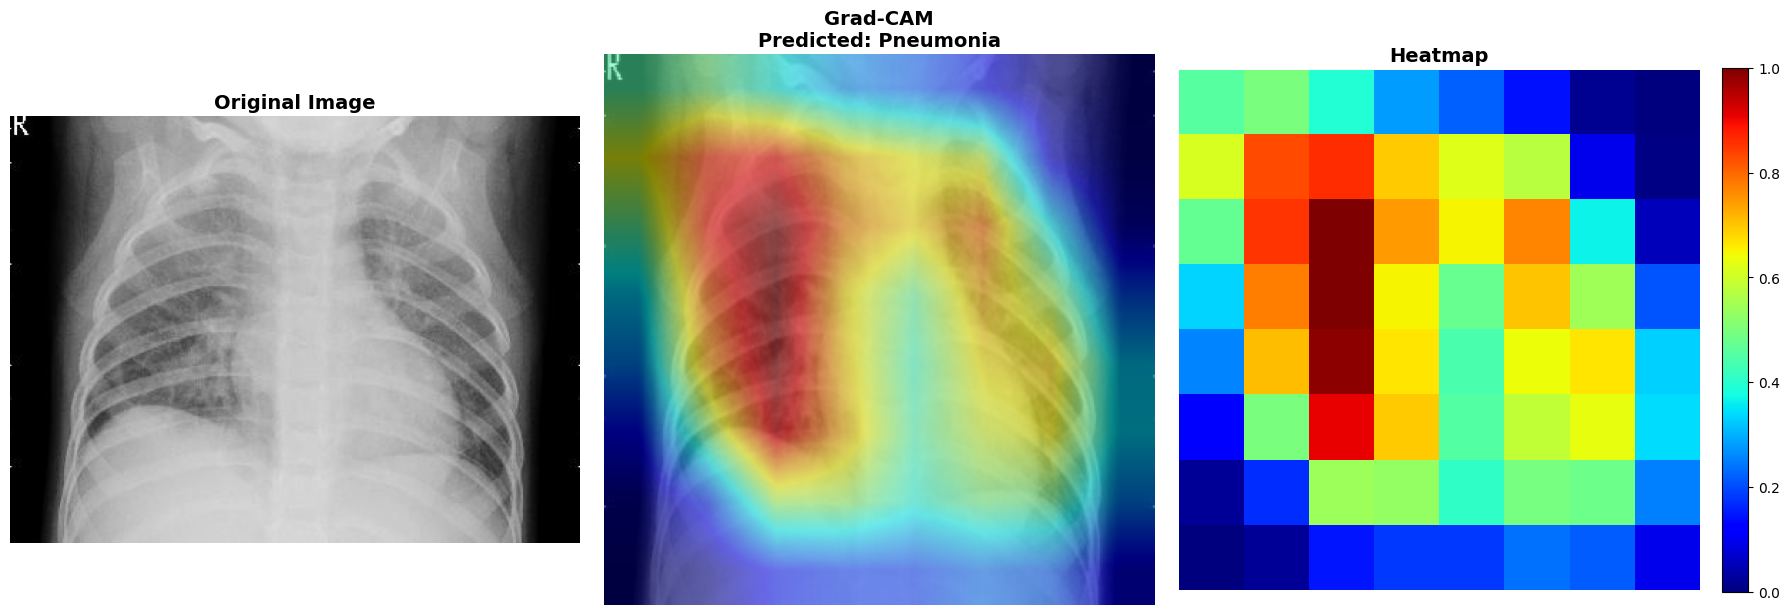


Predicted class for the sample image: Pneumonia
Model: InceptionV3 + ViT


In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

# 1. Choose appropriate target layers for InceptionV3
# Target the last mixed layer before average pooling
target_layer_cnn = 'Mixed_7c'
# For ViT, target the last encoder layer
target_layer_vit = 'encoder.layer.11'

# 2. Create an instance of the GradCAM class
grad_cam = GradCAM(model, target_layer_cnn, target_layer_vit)

# Ensure sample_image_path is not None
if sample_image_path is None:
    raise ValueError("No sample image path found. Please ensure test_dir contains images.")

# 3. Preprocess the sample_image_path
input_tensor = preprocess_image(sample_image_path).to(device)

# 4. Generate the Grad-CAM heatmap
heatmap = grad_cam(input_tensor)

# 5. Get the model's prediction for the preprocessed image
model.eval()
with torch.no_grad():
    output = model(input_tensor)
    predicted_class_idx = output.argmax(dim=1).item()

# 6. Convert the predicted class index back to a human-readable class name
idx_to_class = {v: k for k, v in class_to_idx.items()}
predicted_class_name = idx_to_class[predicted_class_idx]

# Load the original image for display
original_image_pil = Image.open(sample_image_path).convert('RGB')

# 7. Superimpose the heatmap onto the original image
superimposed_image = GradCAM.superimpose_heatmap(input_tensor, heatmap)

# 8. Display the original image, the predicted class, and the superimposed heatmap
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original_image_pil)
plt.title("Original Image", fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(superimposed_image)
plt.title(f"Grad-CAM\nPredicted: {predicted_class_name}", fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(heatmap, cmap='jet')
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Heatmap", fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nPredicted class for the sample image: {predicted_class_name}")
print(f"Model: InceptionV3 + ViT")

---

## **Google Colab Usage Notes**

### **Important Points:**
1. **GPU Runtime**: Make sure to enable GPU in Colab (Runtime → Change runtime type → GPU)
2. **Dataset Path**: The Kaggle dataset will be downloaded automatically via `kagglehub`
3. **Memory Management**: InceptionV3 + ViT is memory-intensive. If you run into memory issues:
   - Reduce `BATCH_SIZE` (try 16 or 8)
   - Reduce `EPOCHS` if needed
4. **Training Time**: With GPU, expect ~2-5 minutes per epoch depending on dataset size
5. **Saved Files**: Model and class mapping will be saved in the Colab session storage

### **Expected Outputs:**
✓ Combined pneumonia class with bacterial + viral samples  
✓ 4-class classification model (Normal, COVID-19, Lung Opacity, Pneumonia)  
✓ Training loss and accuracy curves  
✓ Confusion matrix heatmap  
✓ Per-class performance metrics (Precision, Recall, F1, Accuracy)  
✓ ROC curves for all classes with AUC scores  
✓ Sample distribution visualization  
✓ Grad-CAM visualization for model interpretability  

### **Model Performance Metrics:**
The notebook provides comprehensive evaluation including:
- Overall test accuracy
- Per-class precision, recall, F1-score
- Confusion matrix with counts
- ROC-AUC scores for each class
- Visual performance comparisons

Enjoy your lung disease classification model! 🚀